In [2]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error

In [3]:
def sigmoid(x: torch.Tensor) -> torch.Tensor:
    return 1.0 / (1.0 + torch.exp(-x))


def nll_loss(preds: torch.Tensor, targets: torch.Tensor) -> float:
    eps = 1e-12
    preds = torch.clamp(preds, eps, 1 - eps)
    loss = -(targets * torch.log(preds) + (1 - targets) * torch.log(1 - preds))
    return loss.mean().item()


def train_neuron_batch(X, y, initial_w, initial_b, lr=0.1, epochs=50, verbose=False, print_every=10):
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    w = torch.tensor(initial_w, dtype=torch.float32)
    b = torch.tensor(initial_b, dtype=torch.float32)

    losses = []
    initial_loss = round(nll_loss(sigmoid(X.matmul(w) + b), y), 4)
    losses.append(initial_loss)
    print(f'[Batch] epoch {0}/{epochs} loss={initial_loss}')

    for ep in range(1, epochs + 1):
        z = X.matmul(w) + b
        p = sigmoid(z)
        err = p - y
        grad_w = (err.unsqueeze(1) * X).mean(dim=0)
        grad_b = err.mean()
        w = w - lr * grad_w
        b = b - lr * grad_b
        loss = round(nll_loss(sigmoid(X.matmul(w) + b), y), 4)
        losses.append(loss)
        if verbose and (ep % print_every == 0 or ep == 1 or ep == epochs):
            print(f'[Batch] epoch {ep}/{epochs} loss={loss}')
    return w.tolist(), float(b.item()), losses


def train_neuron_sgd(X, y, initial_w, initial_b, lr=0.01, epochs=50, verbose=False, print_every=10):
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)
    w = torch.tensor(initial_w, dtype=torch.float32)
    b = torch.tensor(initial_b, dtype=torch.float32)
    n = X.shape[0]

    losses = []
    initial_loss = round(nll_loss(sigmoid(X.matmul(w) + b), y), 4)
    losses.append(initial_loss)
    print(f'[SGD] epoch {0}/{epochs} loss={initial_loss}')
    
    for ep in range(1, epochs + 1):
        perm = torch.randperm(n)
        for i in perm:
            xi = X[i]
            yi = y[i]
            z = torch.dot(w, xi) + b
            p = sigmoid(z)
            err = p - yi
            grad_w = err * xi
            grad_b = err
            w = w - lr * grad_w
            b = b - lr * grad_b
        loss = round(nll_loss(sigmoid(X.matmul(w) + b), y), 4)
        losses.append(loss)
        if verbose and (ep % print_every == 0 or ep == 1 or ep == epochs):
            print(f'[SGD] epoch {ep}/{epochs} loss={loss}')
    return w.tolist(), float(b.item()), losses


In [4]:
x_path = "data/train_x.csv"
y_path = "data/train_y.csv"

df_x = pd.read_csv(x_path, index_col=0)
df_y = pd.read_csv(y_path, index_col=0)

print('X shape:', df_x.shape)
print('y shape:', df_y.shape)

df_x.head()

X shape: (14000, 90)
y shape: (14000, 1)


,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
133081,37.47518,-14.34414,40.54872,-9.10171,16.77175,-17.77113,-16.50156,-4.09543,2.49723,-0.46428,...,104.03557,-115.62803,-13.79660,31.60436,28.95927,-25.93164,67.64670,-25.76691,-81.90373,-61.48682
111484,48.17393,-7.02208,-30.36086,-2.41924,2.15406,-8.44502,-1.68191,-8.71434,-7.83802,-5.58019,...,11.58664,24.58950,-36.95682,0.73922,-0.06330,53.75838,-81.05330,8.42811,12.08694,-1.91676
448402,36.58141,26.03203,-4.92774,35.71620,8.53080,3.73167,-7.98443,-7.43976,-1.69797,10.75028,...,23.61190,-366.07968,-62.38201,113.48188,4.72741,181.64459,-134.46216,8.50795,94.15573,-8.47276
254414,41.15615,-17.77029,-32.30961,-21.03778,12.80330,-13.48031,-3.14951,-7.62647,-4.48901,-4.29075,...,25.11398,-79.64532,-77.08169,38.88094,28.52025,24.17783,-86.62542,-1.19418,-74.73449,-17.28130
272580,40.54855,78.77563,-23.29877,98.60192,-30.11496,26.94220,-8.87771,-3.23280,-1.04841,31.69655,...,-9.89388,-252.61021,118.93768,-155.87390,51.85666,-365.15815,59.34936,52.47311,99.00695,-10.18840


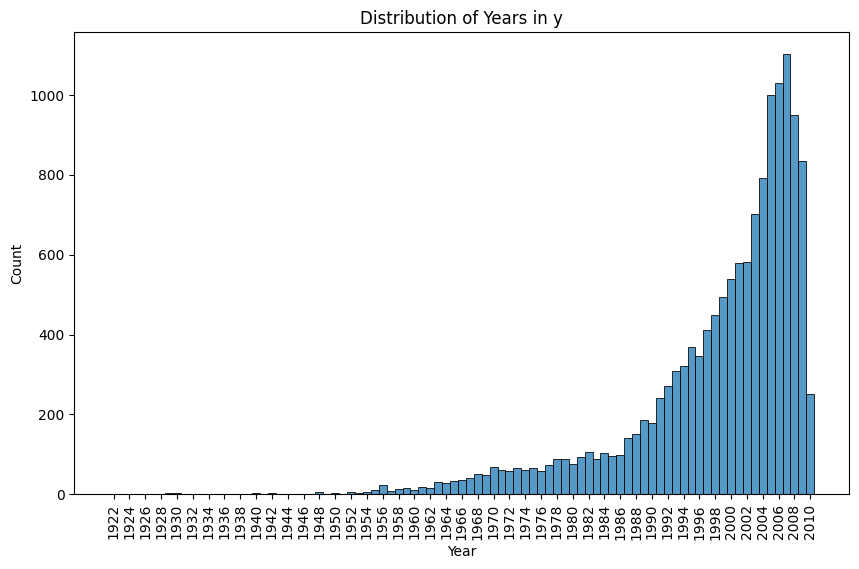

In [5]:
#Распределение y по годам (конкретные года, все), отображай также год

years = df_y['year'].values
plt.figure(figsize=(10, 6))
sns.histplot(years, bins=np.arange(years.min(), years.max() + 1) - 0.5, kde=False)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of Years in y')
plt.xticks(range(years.min(), years.max() + 1, 2), rotation=90)
plt.show()

In [6]:
years = df_y['year'].reindex(df_x.index).to_numpy()
X = df_x.to_numpy(dtype=float)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-6
Xn = (X - X_mean) / X_std

print('Xn shape:', Xn.shape)

targets = [2005, 2009]
results = {}

for t in targets:
    ybin = (years == t).astype(int)
    pos = int(ybin.sum())
    neg = int((1 - ybin).sum())
    print(f'\n--- Target {t} ---')
    print(f'Class balance: positive={pos}, negative={neg}, positive_fraction={pos/len(ybin):.4f}')

    init_w = [0.0] * Xn.shape[1]
    init_b = 0.0

    w_sgd, b_sgd, losses_sgd = train_neuron_sgd(Xn, ybin, init_w, init_b, lr=0.0001, epochs=50, verbose=True, print_every=10)
    w_batch, b_batch, losses_batch = train_neuron_batch(Xn, ybin, init_w, init_b, lr=0.1, epochs=150, verbose=True, print_every=10)
    
    Xn_t = torch.tensor(Xn, dtype=torch.float32)
    w_sgd_t = torch.tensor(w_sgd, dtype=torch.float32)
    w_batch_t = torch.tensor(w_batch, dtype=torch.float32)
    p_sgd = sigmoid(Xn_t.matmul(w_sgd_t) + float(b_sgd))
    p_batch = sigmoid(Xn_t.matmul(w_batch_t) + float(b_batch))
    preds_sgd = (p_sgd >= 0.5).int().numpy()
    preds_batch = (p_batch >= 0.5).int().numpy()
    acc_sgd = accuracy_score(ybin, preds_sgd)
    acc_batch = accuracy_score(ybin, preds_batch)
    mse_sgd = mean_squared_error(ybin, preds_sgd)
    mse_batch = mean_squared_error(ybin, preds_batch)
    results[t] = {
        'w_sgd': w_sgd,
        'b_sgd': b_sgd,
        'losses_sgd': losses_sgd,
        'acc_sgd': acc_sgd,
        'mse_sgd': mse_sgd,
        'w_batch': w_batch,
        'b_batch': b_batch,
        'losses_batch': losses_batch,
        'acc_batch': acc_batch,
        'mse_batch': mse_batch,
    }
    print(f'Target {t}: SGD acc {acc_sgd:.4f}, Batch acc {acc_batch:.4f}')


Xn shape: (14000, 90)

--- Target 2005 ---
Class balance: positive=1001, negative=12999, positive_fraction=0.0715
[SGD] epoch 0/50 loss=0.6931
[SGD] epoch 1/50 loss=0.5063
[SGD] epoch 10/50 loss=0.2643
[SGD] epoch 20/50 loss=0.2517
[SGD] epoch 30/50 loss=0.2495
[SGD] epoch 40/50 loss=0.2488
[SGD] epoch 50/50 loss=0.2483
[Batch] epoch 0/150 loss=0.6931
[Batch] epoch 1/150 loss=0.6749
[Batch] epoch 10/150 loss=0.5462
[Batch] epoch 20/150 loss=0.456
[Batch] epoch 30/150 loss=0.3986
[Batch] epoch 40/150 loss=0.3606
[Batch] epoch 50/150 loss=0.3344
[Batch] epoch 60/150 loss=0.3158
[Batch] epoch 70/150 loss=0.3022
[Batch] epoch 80/150 loss=0.292
[Batch] epoch 90/150 loss=0.2842
[Batch] epoch 100/150 loss=0.2782
[Batch] epoch 110/150 loss=0.2734
[Batch] epoch 120/150 loss=0.2696
[Batch] epoch 130/150 loss=0.2665
[Batch] epoch 140/150 loss=0.264
[Batch] epoch 150/150 loss=0.262
Target 2005: SGD acc 0.9284, Batch acc 0.9284

--- Target 2009 ---
Class balance: positive=835, negative=13165, posit

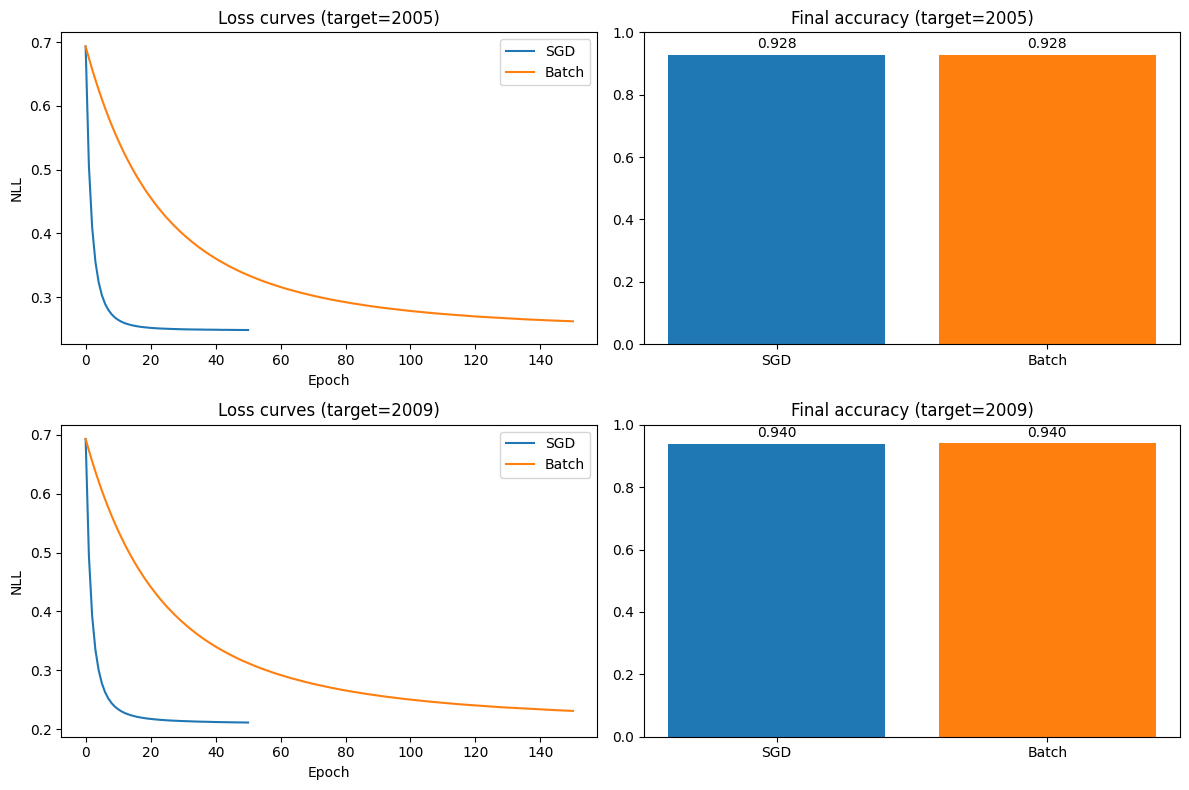

In [7]:
fig, axes = plt.subplots(len(targets), 2, figsize=(12, 4 * len(targets)))
if len(targets) == 1:
    axes = [axes]
for i, t in enumerate(targets):
    res = results[t]
    ax1 = axes[i][0]
    ax1.plot(res['losses_sgd'], label='SGD')
    ax1.plot(res['losses_batch'], label='Batch')
    ax1.set_title(f'Loss curves (target={t})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('NLL')
    ax1.legend()

    ax2 = axes[i][1]
    accs = [res['acc_sgd'], res['acc_batch']]
    ax2.bar(['SGD', 'Batch'], accs, color=['C0','C1'])
    ax2.set_ylim(0,1)
    ax2.set_title(f'Final accuracy (target={t})')
    for j, v in enumerate(accs):
        ax2.text(j, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()


# Оптимизаторы Momentum и Nesterov (NAG)

- Momentum (Polyak): накапливает «скорость» в направлении среднего градиента. v_t = μ v_{t-1} + g_t;  w_{t+1} = w_t - η v_t



- Nesterov (NAG): как Momentum, но с «подсмотром вперёд», что даёт более осторожные шаги. v_t = μ v_{t-1} + g_t;  w_{t+1} = w_t - η (g_t + μ v_t)


In [8]:
import numpy as np
from optimizers import Momentum, NAG


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def forward(w, b, X):
    return sigmoid(X @ w + b)


def binary_cross_entropy(p, y):
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def grad_wb(w, b, X, y):
    p = forward(w, b, X)
    err = p - y
    gw = X.T @ err / X.shape[0]
    gb = float(np.mean(err))
    return gw, gb


# Инициализация одинаковая для честного сравнения
rng = np.random.default_rng(0)
D = Xn.shape[1]
init_w = rng.normal(scale=0.1, size=D)
init_b = 0.0

T = 200
lr = 0.5
mu = 0.9

# SGD (для сравнения)
w_sgd = init_w.copy(); b_sgd = init_b
losses_sgd = []
for t in range(T):
    gw, gb = grad_wb(w_sgd, b_sgd, Xn, ybin)
    w_sgd = w_sgd - lr * gw
    b_sgd = b_sgd - lr * gb
    p = forward(w_sgd, b_sgd, Xn)
    losses_sgd.append(binary_cross_entropy(p, ybin))

# Momentum
w_m = init_w.copy(); b_m = init_b
opt_m_w = Momentum(lr=lr, momentum=mu)
opt_m_b = Momentum(lr=lr, momentum=mu)
losses_m = []
for t in range(T):
    gw, gb = grad_wb(w_m, b_m, Xn, ybin)
    w_m = opt_m_w.step(w_m, gw)
    b_m = opt_m_b.step(b_m, gb)
    p = forward(w_m, b_m, Xn)
    losses_m.append(binary_cross_entropy(p, ybin))

# Nesterov
w_n = init_w.copy(); b_n = init_b
opt_n_w = NAG(lr=lr, momentum=mu)
opt_n_b = NAG(lr=lr, momentum=mu)
losses_n = []
for t in range(T):
    gw, gb = grad_wb(w_n, b_n, Xn, ybin)
    w_n = opt_n_w.step(w_n, gw)
    b_n = opt_n_b.step(b_n, gb)
    p = forward(w_n, b_n, Xn)
    losses_n.append(binary_cross_entropy(p, ybin))

results = {
    "SGD": losses_sgd[-1],
    "Momentum": losses_m[-1],
    "NAG": losses_n[-1],
}
print("Final BCE:", results)

Final BCE: {'SGD': np.float64(0.21016335075519327), 'Momentum': np.float64(0.20845210681884316), 'NAG': np.float64(0.20845210904578643)}


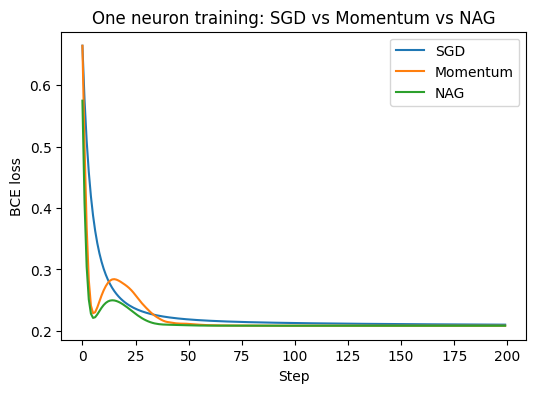

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(losses_sgd, label='SGD')
plt.plot(losses_m, label='Momentum')
plt.plot(losses_n, label='NAG')
plt.xlabel('Step')
plt.ylabel('BCE loss')
plt.title('One neuron training: SGD vs Momentum vs NAG')
plt.legend()
plt.show()